In [16]:
import anndata
import pandas as pd
import scimap as sm
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy.cluster.hierarchy import linkage, leaves_list
import matplotlib.colors as mcolors


This script performs NEP analysis on the MI dataset with COZI using the github scimap fork https://github.com/chiarasch/scimap/

In [2]:
path_to_csv = './../../../../../data/leaat_breast/mibi_tnbc_meta.csv'
path_to_metadata = './../../../../../data/leaat_breast/architecture_annotation.xlsx'
obs = pd.read_csv(path_to_csv)
output_path = './../../../../Comparison/202506_results_MI_resolve/leeat_COZI_normalized_knn5.csv'
NEP_method = "COZI"
label = 'COZI_knn5'

In [3]:
# read and checkout metadata.xlsx
metadata = pd.read_excel(path_to_metadata)
# order metadata based on spatial architecture
metadata = metadata.sort_values(by="Spatial Architecture")
metadata


,SampleID,Spatial Architecture
0,24,Cold
1,26,Cold
2,15,Cold
3,22,Cold
4,19,Cold
5,25,Cold
24,40,Compartmentalized
26,5,Compartmentalized
27,41,Compartmentalized
28,10,Compartmentalized


In [4]:
#create anndata object
# add marker files to it, as SpatialLDA needs them
obs['D'] = np.random.randint(1, 101, size=len(obs))
obs['E'] = np.random.randint(1, 101, size=len(obs))

# Ensure obs has a string-based index
obs.index = obs.index.astype(str)  # Convert index to string


# Load dataframe into anndata object
# the data matrix 
X = obs[['D', 'E']]
X = X.values
adata = anndata.AnnData(X)
adata.obs = obs
adata

AnnData object with n_obs × n_vars = 197678 × 2
    obs: 'Unnamed: 0', 'SampleID', 'cellLabelInImage', 'cellSize', 'tumorYN', 'tumorCluster', 'Group', 'immuneCluster', 'immuneGroup', 'row', 'col', 'D', 'E'

In [5]:
# Create a mapping from cluster ID to cell type
sample_to_architecture = metadata.set_index("SampleID")["Spatial Architecture"]
# Map the cell type to adata.obs using the Imaging phenotype cluster ID
adata.obs["spatial_architecture"] = adata.obs["SampleID"].map(sample_to_architecture)
adata.obs['Group'] = adata.obs['Group'].astype(str)

In [6]:
NEP_method = 'COZI'
label = 'COZI_delaunay'

In [7]:
# Define the spatial interaction analysis
spatial_params = {
    'adata': adata,
    'x_coordinate': 'row',
    'y_coordinate': 'col',
    'phenotype': 'Group',
    'method': 'delaunay',
    'knn': 5,
    'permutation': 300,
    'imageid': 'SampleID',
    'subset': None,
    'pval_method': 'zscore',
    'verbose': True,
    'label': label
}

# Conditionally include normalization based on method
if NEP_method == 'SEA':
    spatial_params['normalization'] = 'total'  # Example of adding normalization for 'knn'
if NEP_method == 'COZI':
    spatial_params['normalization'] = 'conditional'  # Example of adding normalization for 'knn'
    
# Run spatial interaction analysis with the conditional parameter
adata = sm.tl.spatial_interaction(**spatial_params)


Processing Image: [1]
Retaining 5 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: [2]
Retaining 4 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: [3]
Retaining 6 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: [4]
Retaining 6 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: [5]
Retaining 6 phenotypes with ≥ 10 cells
Performing Delaunay

In [8]:
spatial_params['normalization'] = 'total'
spatial_params['label'] = 'SEA_delaunay'

spatial = sm.tl.spatial_interaction(**spatial_params)

Processing Image: [1]
Retaining 5 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: [2]
Retaining 4 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: [3]
Retaining 6 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: [4]
Retaining 6 phenotypes with ≥ 10 cells
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: [5]
Retaining 6 phenotypes with ≥ 10 cells
Performing Delaunay

In [18]:
# start with COZI:
label = 'COZI_delaunay'

interactions_of_interest = [
    'Immune_Immune',
    'Immune_Keratin-positive tumor',
    'Keratin-positive tumor_Immune',
    'Keratin-positive tumor_Keratin-positive tumor',
]

In [19]:
# Start with the wide format `save_df` from `adata.uns`
df = adata.uns[label].copy()

# Create 'interaction' and melt to long format in a single step
df['interaction'] = df['phenotype'].astype(str) + '_' + df['neighbour_phenotype'].astype(str)
df_long = df.melt(id_vars=['phenotype', 'neighbour_phenotype', 'interaction'], var_name='metric', value_name='value')

# Extract metric type and condition, then pivot
df_long[['metric_type', 'condition']] = df_long['metric'].str.extract(r'^(zscore|cond_cell_ratio)_(.*)')
df_pivot = df_long.pivot_table(index=['interaction', 'condition'], columns='metric_type', values='value').reset_index()

# Convert numeric columns and handle missing/infinite values
df_pivot['zscore'] = pd.to_numeric(df_pivot['zscore'], errors='coerce').fillna(0).replace([np.inf, -np.inf], 0)
df_pivot['cond_cell_ratio'] = pd.to_numeric(df_pivot['cond_cell_ratio'], errors='coerce').fillna(0)

# Filter by `interactions_of_interest` and sort by `condition`
df_filtered = df_pivot[df_pivot['interaction'].isin(interactions_of_interest)].copy()

# Ensure `condition` and `interaction` are correctly ordered categorical types
df_filtered['condition'] = pd.Categorical(df_filtered['condition'].astype(str), categories=metadata['SampleID'].astype(str).tolist(), ordered=True)
df_filtered['interaction'] = pd.Categorical(df_filtered['interaction'], categories=interactions_of_interest, ordered=True)
df_filtered = df_filtered.sort_values('condition')

# Prepare group data and merge
group_df = sample_to_architecture.rename_axis('condition').reset_index()
group_df.columns = ['condition', 'Group']
df_filtered['condition'] = df_filtered['condition'].astype(str)
group_df['condition'] = group_df['condition'].astype(str)
df_merged = df_filtered.merge(group_df, on='condition', how='left')

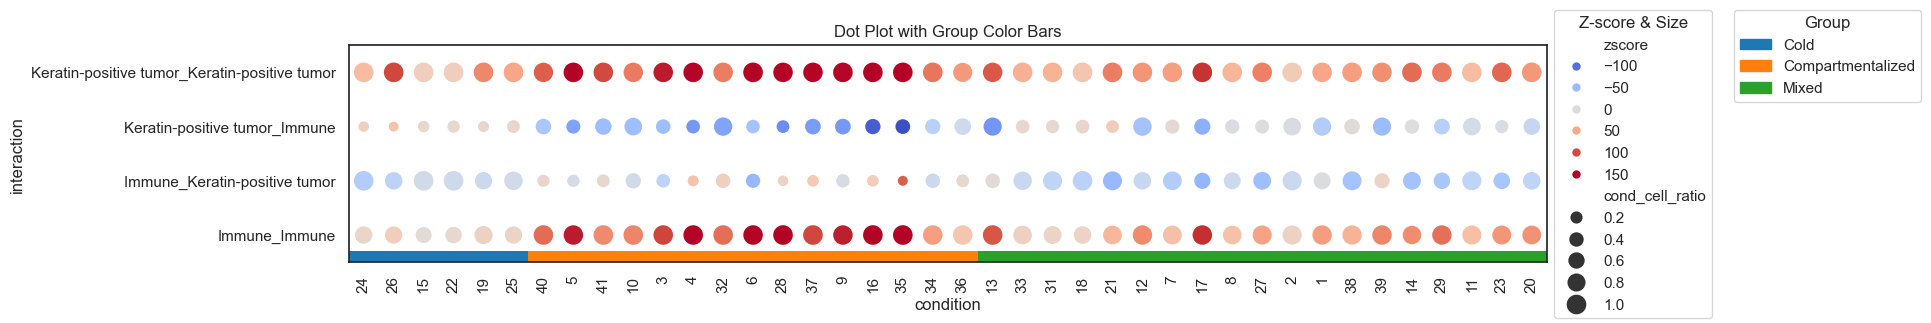

In [20]:
df = df_merged
df['condition'] = pd.Categorical(df['condition'], categories=df['condition'].unique(), ordered=True)
plt.figure(figsize=(20, 3.5))
ax = plt.gca()

# Scatterplot: x=condition, y=interaction
scatter = sns.scatterplot(
    data=df,
    x='condition', y='interaction',
    size='cond_cell_ratio',
    hue='zscore',
    sizes=(50, 200),
    palette='coolwarm',
    edgecolor='gray',
    hue_norm=(-120, 120),
    linewidth=0,
    ax=ax
)

plt.xticks(rotation=90)

padding_y = 0.5
num_interactions = df['interaction'].nunique()
ax.set_ylim(-padding_y, num_interactions - 1 + padding_y)

# Map groups to colors
unique_groups = df['Group'].unique()
palette_groups = sns.color_palette('tab10', n_colors=len(unique_groups))
group_color_dict = dict(zip(unique_groups, palette_groups))

# Draw color bars below x-axis
bar_height = 0.2
for i, cond in enumerate(df['condition'].cat.categories):
    group = df.loc[df['condition'] == cond, 'Group'].iloc[0]
    color = group_color_dict.get(group, 'lightgray')
    rect = patches.Rectangle(
        (i - 0.5, -padding_y),  # bottom-left corner
        width=1,
        height=bar_height,
        linewidth=0,
        facecolor=color,
        clip_on=False
    )
    ax.add_patch(rect)

# Get the existing legend handles and labels from the scatterplot (zscore + size)
handles1, labels1 = ax.get_legend_handles_labels()

# Create legend handles for group color bars
handles2 = [patches.Patch(color=color, label=grp) for grp, color in group_color_dict.items()]

# Add first legend for zscore and size
legend1 = ax.legend(handles=handles1, title='Z-score & Size', bbox_to_anchor=(1, 1.2), loc='upper left')

# Add second legend for groups below the first legend
ax.add_artist(legend1)  # Make sure first legend stays
ax.legend(handles=handles2, title='Group', bbox_to_anchor=(1.15, 1.2), loc='upper left')
ax.set_xlim(-0.5, len(df['condition'].cat.categories) - 0.5)

plt.title('Dot Plot with Group Color Bars')
plt.tight_layout()

# Save as SVG
#plt.savefig("./../../../../../Paper_figures/202506_dotplots/TNBC_MIBI_cozi_dotplot_colorbars_all.svg", format="svg", bbox_inches='tight')


plt.show()


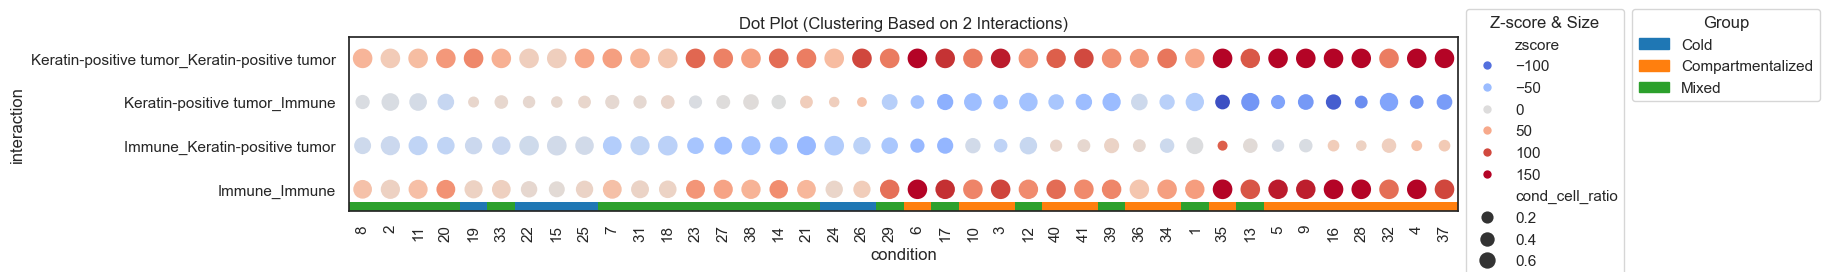

In [21]:
# Clusterinf zscores
df = df_merged.copy()

# Define interactions to use for clustering
clustering_interactions = [
    "Immune_Keratin-positive tumor",
    "Keratin-positive tumor_Immune"
]

# Filter for clustering (only those two interactions)
df_clustering = df[df['interaction'].isin(clustering_interactions)]

# Pivot for clustering
pivot = df_clustering.pivot(index='condition', columns='interaction', values='zscore').fillna(0)

# Perform hierarchical clustering
linkage_matrix = linkage(pivot, method='ward', metric='euclidean')
cluster_order = leaves_list(linkage_matrix)

# Get new clustered condition order
new_order = pivot.index[cluster_order].tolist()

# Ensure consistent types
df['condition'] = df['condition'].astype(str)
df['condition'] = pd.Categorical(df['condition'], categories=new_order, ordered=True)

# --- Plotting ---
plt.figure(figsize=(19, 3))
ax = plt.gca()

# Scatterplot: all interactions shown
scatter = sns.scatterplot(
    data=df,
    x='condition', y='interaction',
    size='cond_cell_ratio',
    hue='zscore',
    sizes=(50, 200),
    palette='coolwarm',
    edgecolor='gray',
    hue_norm=(-120, 120),
    linewidth=0,
    ax=ax
)

plt.xticks(rotation=90)

padding_y = 0.5
num_interactions = df['interaction'].nunique()
ax.set_ylim(-padding_y, num_interactions - 1 + padding_y)

# Group color mapping
unique_groups = df['Group'].unique()
palette_groups = sns.color_palette('tab10', n_colors=len(unique_groups))
group_color_dict = dict(zip(unique_groups, palette_groups))

# Color bar below x-axis
bar_height = 0.2
for i, cond in enumerate(df['condition'].cat.categories):
    if cond in df['condition'].values:
        group = df.loc[df['condition'] == cond, 'Group'].iloc[0]
        color = group_color_dict.get(group, 'lightgray')
    else:
        color = 'lightgray'
    rect = patches.Rectangle(
        (i - 0.5, -padding_y),
        width=1,
        height=bar_height,
        linewidth=0,
        facecolor=color,
        clip_on=False
    )
    ax.add_patch(rect)

# Legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2 = [patches.Patch(color=color, label=grp) for grp, color in group_color_dict.items()]

legend1 = ax.legend(handles=handles1, title='Z-score & Size', bbox_to_anchor=(1, 1.2), loc='upper left')
ax.add_artist(legend1)
ax.legend(handles=handles2, title='Group', bbox_to_anchor=(1.15, 1.2), loc='upper left')

ax.set_xlim(-0.5, len(df['condition'].cat.categories) - 0.5)

plt.title('Dot Plot (Clustering Based on 2 Interactions)')
plt.tight_layout()

# Optional: save
plt.savefig("./../../../../../Paper_figures/202506_dotplots/TNBC_MIBI_cozi_dotplot_clustered.svg", format="svg", bbox_inches='tight')

plt.show()


In [22]:
# do the same for SEA
label = 'SEA_delaunay'
# Start with the wide format `save_df` from `adata.uns`
df = adata.uns[label].copy()

# Create 'interaction' and melt to long format in a single step
df['interaction'] = df['phenotype'].astype(str) + '_' + df['neighbour_phenotype'].astype(str)
df_long = df.melt(id_vars=['phenotype', 'neighbour_phenotype', 'interaction'], var_name='metric', value_name='value')

# Extract metric type and condition, then pivot
df_long[['metric_type', 'condition']] = df_long['metric'].str.extract(r'^(zscore)_(.*)')
df_pivot = df_long.pivot_table(index=['interaction', 'condition'], columns='metric_type', values='value').reset_index()

# Convert numeric columns and handle missing/infinite values
df_pivot['zscore'] = pd.to_numeric(df_pivot['zscore'], errors='coerce').fillna(0).replace([np.inf, -np.inf], 0)


# Filter by `interactions_of_interest` and sort by `condition`
df_filtered = df_pivot[df_pivot['interaction'].isin(interactions_of_interest)].copy()

# Ensure `condition` and `interaction` are correctly ordered categorical types
df_filtered['condition'] = pd.Categorical(df_filtered['condition'].astype(str), categories=metadata['SampleID'].astype(str).tolist(), ordered=True)
df_filtered['interaction'] = pd.Categorical(df_filtered['interaction'], categories=interactions_of_interest, ordered=True)
df_filtered = df_filtered.sort_values('condition')

# Prepare group data and merge
group_df = sample_to_architecture.rename_axis('condition').reset_index()
group_df.columns = ['condition', 'Group']
df_filtered['condition'] = df_filtered['condition'].astype(str)
group_df['condition'] = group_df['condition'].astype(str)
df_merged = df_filtered.merge(group_df, on='condition', how='left')

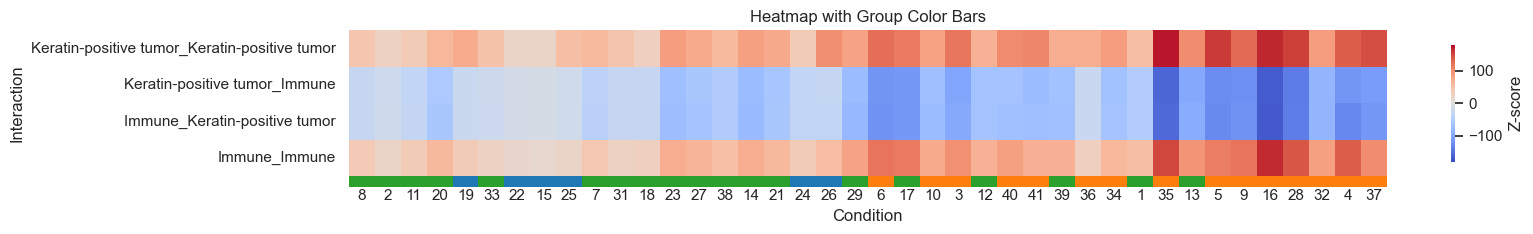

In [24]:

# --- Prepare Data ---
# Preserve original order of interactions as categorical
# Reorder interaction and condition as categorical variables

df=df_merged
df['condition'] = pd.Categorical(df['condition'], categories=df['condition'].unique(), ordered=True)
new_order = pivot.index[cluster_order].tolist()
df['condition'] = pd.Categorical(df['condition'], categories=new_order, ordered=True)

heatmap_data = df.pivot_table(index='interaction', columns='condition', values='zscore')

heatmap_data.index = pd.Categorical(
    heatmap_data.index,
    categories=interactions_of_interest,
    ordered=True
)



# --- Create Figure and Axes ---
fig, ax = plt.subplots(figsize=(19, 2.5))

# --- Heatmap ---
cmap = sns.color_palette("coolwarm", as_cmap=True)
norm = mcolors.TwoSlopeNorm(vmin=-180, vcenter=0, vmax=180)
sns.heatmap(
    heatmap_data,
    cmap=cmap,
    norm=norm,
    cbar_kws={"label": "Z-score", "shrink": 0.8, "aspect": 30},
    ax=ax
)

# --- X-axis group color bars ---
unique_groups = df['Group'].unique()
palette_groups = sns.color_palette('tab10', n_colors=len(unique_groups))
group_color_dict = dict(zip(unique_groups, palette_groups))
bar_height = 0.3

for i, cond in enumerate(df['condition'].cat.categories):
    group = df.loc[df['condition'] == cond, 'Group'].iloc[0]
    color = group_color_dict.get(group, 'lightgray')
    rect = patches.Rectangle(
        (i, -bar_height),
        width=1,
        height=bar_height,
        linewidth=0,
        facecolor=color,
        transform=ax.transData,
        clip_on=False
    )
    ax.add_patch(rect)

# --- Move only Group Legend ---
handles_group = [patches.Patch(color=color, label=grp) for grp, color in group_color_dict.items()]
group_legend = ax.legend(
    handles=handles_group,
    title='Group',
    bbox_to_anchor=(1.3, 1.2),
    loc='upper left'
)
ax.add_artist(group_legend)

# --- Axis Labels ---
ax.set_xlabel('Condition')
ax.invert_yaxis()
ax.set_ylabel('Interaction')
ax.set_title('Heatmap with Group Color Bars')

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig("./../../../../../Paper_figures/202506_dotplots/TNBC_MIBI_sea_heatmap_clustered.svg", format="svg", bbox_inches='tight')

plt.show()


